<a href="https://colab.research.google.com/github/gouribolloju-oss/customer-churn-analysis/blob/main/project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Executive Summary

## Key Findings

1. Customers in their first 12 months have the highest churn rate (47.68%).

2. Month-to-month contracts have the highest churn rate (42.71%).

3. Electronic check customers have the highest churn rate (45.29%).

4. Customers without Tech Support have a churn rate of 41.64%.

## Recommendations

- Focus retention efforts on new customers.
- Encourage customers to move to longer-term contracts.
- Promote automatic payment methods.
- Increase adoption of Tech Support services.

Importing libraries


In [1]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.xlsx to WA_Fn-UseC_-Telco-Customer-Churn.xlsx


Loading Dataset


In [2]:
import pandas as pd

df = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn.xlsx")

print(df.shape)

df.head()

(7043, 1)


,"customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn"
0,"7590-VHVEG,Female,0,Yes,No,1,No,No phone servi..."
1,"5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Y..."
2,"3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,N..."
3,"7795-CFOCW,Male,0,No,No,45,No,No phone service..."
4,"9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic..."


In [3]:
import pandas as pd

# Read the bad file
df_raw = pd.read_excel("WA_Fn-UseC_-Telco-Customer-Churn.xlsx", header=None)

# Split the single column into proper columns
df = df_raw[0].str.split(",", expand=True)

# First row becomes column names
df.columns = df.iloc[0]

# Remove first row from data
df = df.iloc[1:].reset_index(drop=True)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.7,151.65,Yes


In [4]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
churn_rate = (1869 / 7043) * 100

print(round(churn_rate, 2))

26.54


Data Cleaning


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        7043 non-null   object
 1   gender            7043 non-null   object
 2   SeniorCitizen     7043 non-null   object
 3   Partner           7043 non-null   object
 4   Dependents        7043 non-null   object
 5   tenure            7043 non-null   object
 6   PhoneService      7043 non-null   object
 7   MultipleLines     7043 non-null   object
 8   InternetService   7043 non-null   object
 9   OnlineSecurity    7043 non-null   object
 10  OnlineBackup      7043 non-null   object
 11  DeviceProtection  7043 non-null   object
 12  TechSupport       7043 non-null   object
 13  StreamingTV       7043 non-null   object
 14  StreamingMovies   7043 non-null   object
 15  Contract          7043 non-null   object
 16  PaperlessBilling  7043 non-null   object
 17  PaymentMethod 

In [8]:
df.isnull().sum()

,0
0,
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [9]:
df["TotalCharges"].dtype

dtype('O')

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["TotalCharges"].dtype

dtype('float64')

missing values


In [12]:
df["TotalCharges"].isnull().sum()

np.int64(11)

fixing missing values

In [13]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [14]:
df["TotalCharges"].isnull().sum()

np.int64(0)

creating Churn Flag


In [15]:
df["Churn_Flag"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [16]:
df[["Churn","Churn_Flag"]].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


creating Tensure groups


In [17]:
df["Tenure_Group"] = pd.cut(
    df["tenure"].astype(int),
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [18]:
df[["tenure","Tenure_Group"]].head()

,tenure,Tenure_Group
0,1,0-12 Months
1,34,25-48 Months
2,2,0-12 Months
3,45,25-48 Months
4,2,0-12 Months


saving cleaned Data


In [19]:
df.to_csv(
    "churn_cleaned.csv",
    index=False
)

KPI analysis


In [20]:
#total customers
total_customers = len(df)

print(total_customers)

7043


In [21]:
#churned customers
churned_customers = (
    df["Churn"] == "Yes"
).sum()

print(churned_customers)

1869


In [22]:
#churn rate
churn_rate = (
    churned_customers
    /
    total_customers
) * 100

print(round(churn_rate,2))

26.54


In [24]:
print(df["MonthlyCharges"].dtype)

object


In [25]:
df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"],
    errors="coerce"
)

In [26]:
print(df["MonthlyCharges"].dtype)

float64


In [28]:
##average monthly charges
avg_monthly = df["MonthlyCharges"].mean()

print(round(avg_monthly, 2))

64.76


In [29]:
df.dtypes

,0
0,
customerID,object
gender,object
SeniorCitizen,object
Partner,object
Dependents,object
tenure,object
PhoneService,object
MultipleLines,object
InternetService,object


In [30]:
df["SeniorCitizen"] = pd.to_numeric(df["SeniorCitizen"], errors="coerce")
df["tenure"] = pd.to_numeric(df["tenure"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [31]:
df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]].dtypes

,0
0,
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64


In [32]:
df[["SeniorCitizen","tenure","MonthlyCharges","TotalCharges"]].dtypes

,0
0,
SeniorCitizen,int64
tenure,int64
MonthlyCharges,float64
TotalCharges,float64


In [33]:
avg_monthly = df["MonthlyCharges"].mean()
print(round(avg_monthly,2))

64.76


In [35]:
#summary table
total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()

churn_rate = round(
    (churned_customers / total_customers) * 100,
    2
)

avg_monthly_charges = round(
    df["MonthlyCharges"].mean(),
    2
)

avg_tenure = round(
    df["tenure"].mean(),
    2
)

revenue_at_risk = round(
    df.loc[df["Churn"]=="Yes","MonthlyCharges"].sum(),
    2
)

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", churn_rate,"%")
print("Average Monthly Charges:", avg_monthly_charges)
print("Average Tenure:", avg_tenure)
print("Revenue At Risk:", revenue_at_risk)

Total Customers: 7043
Churned Customers: 1869
Churn Rate: 26.54 %
Average Monthly Charges: 64.76
Average Tenure: 32.37
Revenue At Risk: 139130.85


In [36]:
#Which contract type churns the most?
contract_churn = (
    df.groupby("Contract")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Flag, dtype: float64


In [37]:
#Which payment method churns the most?
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(payment_churn)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn_Flag, dtype: float64


In [38]:
#Which tenure group churns the most?

df["Tenure_Group"] = pd.cut(
    df["tenure"],
    bins=[0,12,24,48,72],
    labels=[
        "0-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [39]:
tenure_churn = (
    df.groupby("Tenure_Group")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(tenure_churn)

Tenure_Group
0-12 Months     47.678161
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Churn_Flag, dtype: float64


/tmp/ipykernel_1766/4102635109.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Tenure_Group")["Churn_Flag"]


Customers in their first 12 months have the highest churn rate (47.68%).

Customer churn steadily decreases as tenure increases.

Customers with 49–72 months tenure show the lowest churn rate (9.51%).

This suggests the company should focus retention efforts on new customers during their first year.



Visualizations


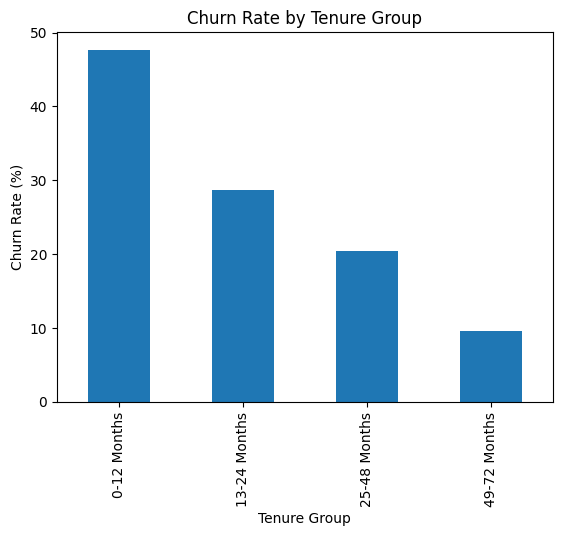

In [41]:

import matplotlib.pyplot as plt

tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [42]:
#Analysis: Contract Type
contract_churn = (
    df.groupby("Contract")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_Flag, dtype: float64


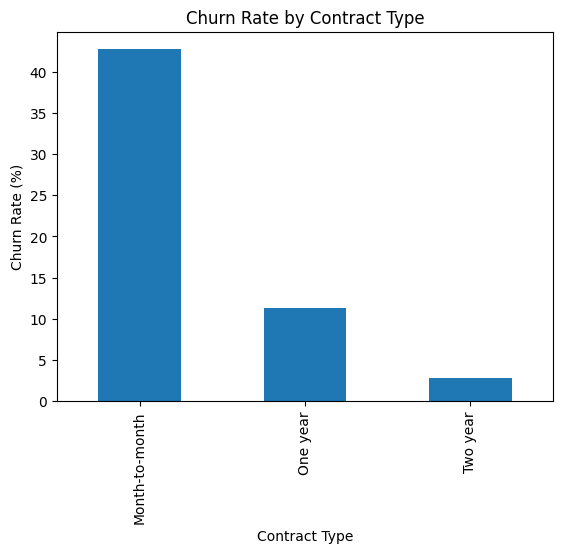

In [43]:
import matplotlib.pyplot as plt

contract_churn.plot(kind="bar")

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [44]:
#payment method
payment_churn = (
    df.groupby("PaymentMethod")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(payment_churn)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn_Flag, dtype: float64


service-related churn drivers.



In [45]:
#Internet Service
internet_churn = (
    df.groupby("InternetService")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(internet_churn)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn_Flag, dtype: float64


In [46]:
#online security
security_churn = (
    df.groupby("OnlineSecurity")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(security_churn)

OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn_Flag, dtype: float64


In [47]:
#tech support
tech_churn = (
    df.groupby("TechSupport")["Churn_Flag"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

print(tech_churn)

TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn_Flag, dtype: float64


creating visualizations


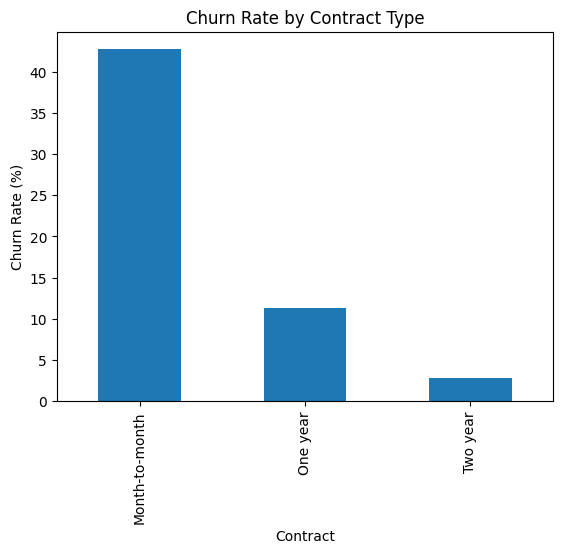

In [48]:
#1
import matplotlib.pyplot as plt

contract_churn.plot(kind='bar')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.show()

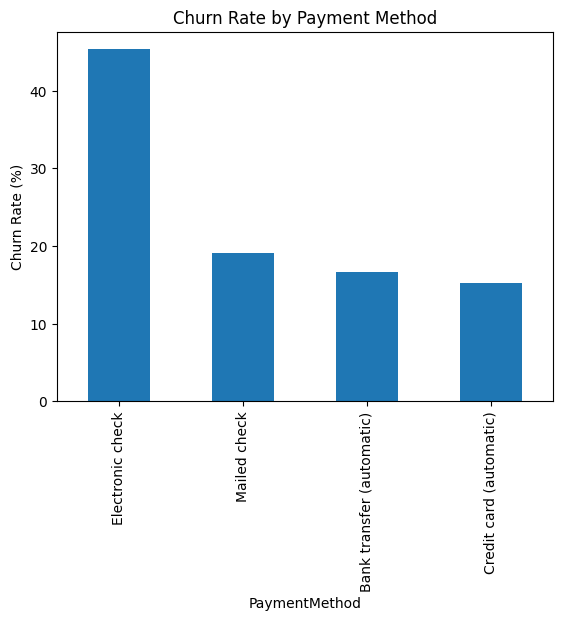

In [49]:
#2
payment_churn.plot(kind='bar')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.show()

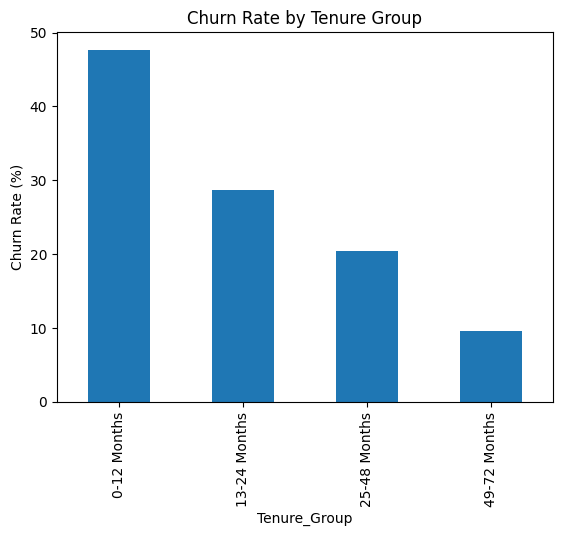

In [50]:
#3
tenure_churn.plot(kind='bar')
plt.title('Churn Rate by Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.show()

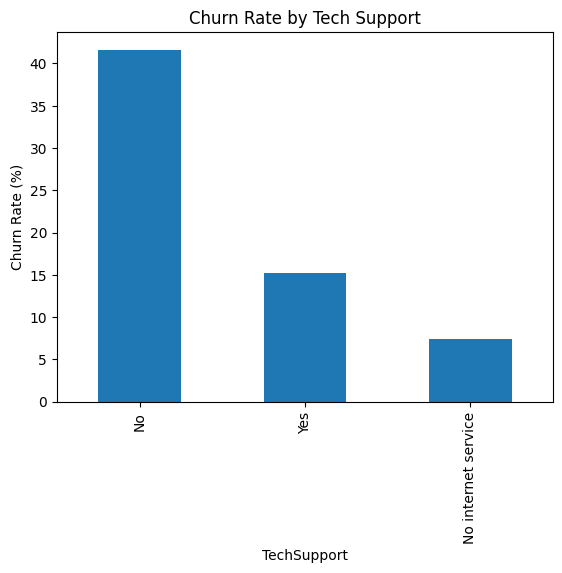

In [51]:
#4
tech_churn.plot(kind='bar')
plt.title('Churn Rate by Tech Support')
plt.ylabel('Churn Rate (%)')
plt.show()

In [52]:
print(df.shape)

(7043, 23)


In [53]:
df.to_csv("churn_cleaned_full.csv", index=False)

In [54]:
from google.colab import files

files.download("churn_cleaned_full.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>